# 3. Modelling

Two tasks, on each sensor type separately:

- **Detection:** leak versus no-leak.
- **Leak type:** which of the five classes.

The earlier notebooks showed that windows of one recording are near-copies, that sensor position and pipe layout dominate the signals, and that some class differences look like recording artefacts. So the question here is not "how high is the accuracy" but "under which test conditions does it survive".

All model fitting is done by `scripts/run_experiments.py`, which saves out-of-fold predictions to `results/`. This notebook analyses those predictions and runs without the raw data.

In [1]:
import sys
import warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

import evaluate as ev
import features as ft
import leakdata as ld
import plotstyle as ps

ps.apply()
pd.set_option("display.width", 200)
RESULTS = ld.REPO_ROOT / "results"
metrics = pd.read_csv(RESULTS / "metrics.csv")
by_fold = pd.read_csv(RESULTS / "metrics_by_fold.csv")
oof = pd.read_parquet(RESULTS / "oof_predictions.parquet")

CHANCE = {"detect": 0.5, "type": 0.2}
TASK_NAMES = {"detect": "Detection (leak vs no-leak)", "type": "Leak type (5 classes)"}
MODEL_NAMES = {"logreg": "Logistic regression", "rf": "Random forest", "lgbm": "Gradient boosting", "cnn": "CNN on spectrograms"}
MODEL_COLORS = {"logreg": "#2a78d6", "rf": "#eb6834", "lgbm": "#1baf7a", "cnn": "#eda100"}
print(len(metrics), "model configurations,", f"{len(oof):,}", "out-of-fold window predictions")

168 model configurations, 577,976 out-of-fold window predictions


## 3.1 Setup

**Inputs.** Classical models use the 22 scale-invariant window features from notebook 2 ("shape"), optionally with signal level added ("shape+amplitude"). The CNN uses a 64 x 32 log-spectrogram of each window, standardised per window so it also carries no absolute level.

**Models.** Logistic regression, random forest, gradient boosting (LightGBM) and a small three-layer CNN. Every hyperparameter is fixed in `src/evaluate.py` and nothing is tuned, so no score below was selected from a search. The random forest on shape features was chosen in advance as the reference model for the detailed analysis.

**Evaluation protocols**, from most to least optimistic:

| Protocol | What is held out | What it tests |
|---|---|---|
| Random windows | 20% of windows at random | Nothing useful: test windows come from recordings seen in training. Included to show the size of the leak. |
| Held-out tests | 8 of the 40 physical tests per fold, all sensors and takes together | New recordings of conditions like those seen in training. |
| Held-out flow condition | One of the four flow conditions | A flow regime never seen in training. |
| Held-out pipe layout | One of the two layouts | A different network. The closest thing here to deployment. |

**Metric.** Balanced accuracy at recording level: window probabilities are averaged over each recording, and the recall of each class is averaged. Chance is 0.50 for detection and 0.20 for leak type, whatever the class balance.

## 3.2 Headline results

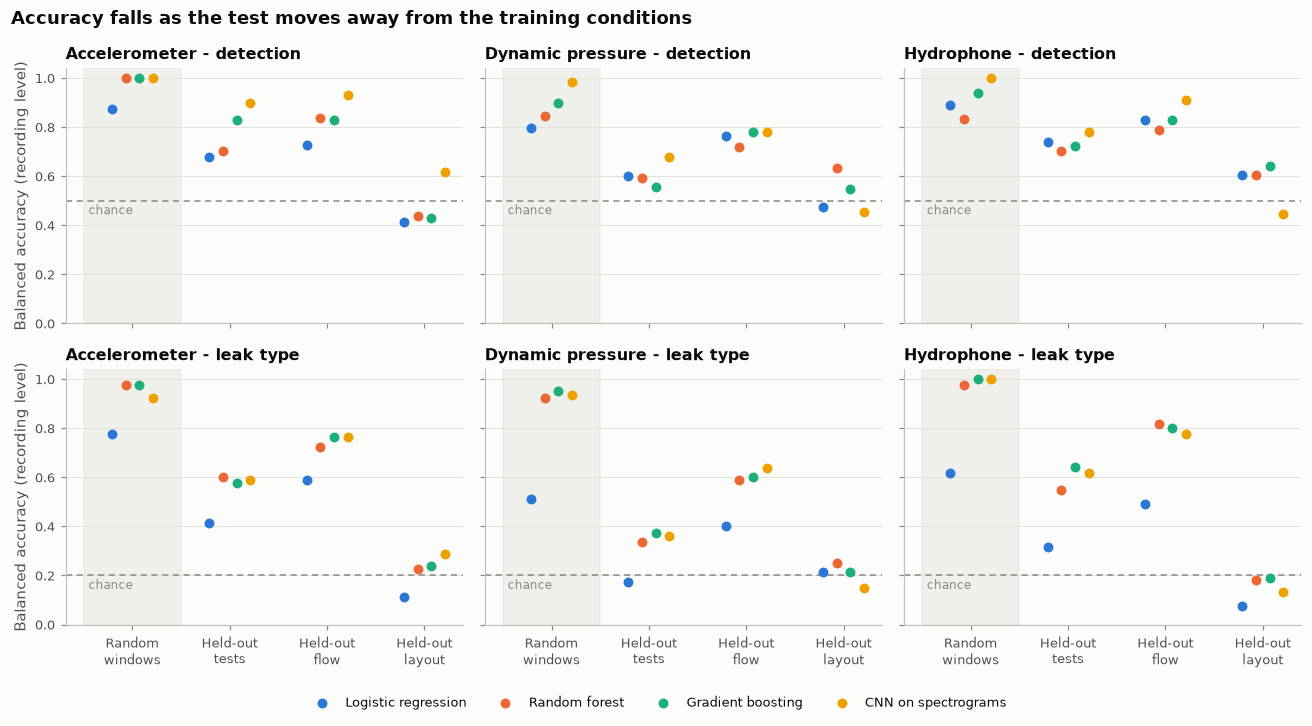

In [2]:
main = metrics[metrics.feature_set.isin(["shape", "spectrogram"])]

def headline(metric="recording_bal_acc"):
    fig, axes = plt.subplots(2, 3, figsize=(12, 6.6), sharey="row", sharex=True)
    for r, task in enumerate(ev.TASKS):
        for c, stype in enumerate("APH"):
            ax = axes[r, c]
            d = main[(main.task == task) & (main.sensor_type == stype)]
            for k, model in enumerate(MODEL_NAMES):
                v = d[d.model == model].set_index("protocol")[metric].reindex(ev.PROTOCOLS)
                ax.scatter(np.arange(4) + (k - 1.5) * 0.14, v, s=42, color=MODEL_COLORS[model], label=MODEL_NAMES[model], zorder=3, linewidths=0)
            ax.axhline(CHANCE[task], color=ps.MUTED, lw=1, ls=(0, (4, 3)), zorder=1)
            ax.text(-0.45, CHANCE[task] - 0.055, "chance", ha="left", fontsize=8, color=ps.MUTED)
            ax.set_ylim(0, 1.04)
            ax.set_xticks(range(4), ["Random\nwindows", "Held-out\ntests", "Held-out\nflow", "Held-out\nlayout"])
            ax.set_title(f"{ld.SENSOR_NAMES[stype]} - {TASK_NAMES[task].split(' (')[0].lower()}")
            ax.grid(axis="x", visible=False)
            ax.axvspan(-0.5, 0.5, color=ps.GRID, alpha=0.45, zorder=0)
        axes[r, 0].set_ylabel("Balanced accuracy (recording level)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, 0))
    fig.suptitle("Accuracy falls as the test moves away from the training conditions", x=0.01, ha="left", fontsize=12, fontweight="bold")
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    plt.show()

headline()

In [3]:
table = main.pivot_table(index=["task", "sensor_type", "model"], columns="protocol", values="recording_bal_acc")[ev.PROTOCOLS]
table = table.reindex(pd.MultiIndex.from_product([ev.TASKS, list("APH"), MODEL_NAMES]))
table.rename(index=TASK_NAMES, level=0).rename(index=ld.SENSOR_NAMES, level=1).rename(index=MODEL_NAMES, level=2).rename(columns=ev.PROTOCOL_NAMES).round(2)

protocol                                                          Random windows (leaky)  Held-out tests  Held-out flow condition  Held-out pipe layout
Detection (leak vs no-leak) Accelerometer    Logistic regression                    0.88            0.68                     0.73                  0.41
                                             Random forest                          1.00            0.70                     0.84                  0.44
                                             Gradient boosting                      1.00            0.83                     0.83                  0.43
                                             CNN on spectrograms                    1.00            0.90                     0.93                  0.62
                            Dynamic pressure Logistic regression                    0.80            0.60                     0.77                  0.48
                                             Random forest                          0.84            0.59                     0.72                  0.63
                                             Gradient boosting                      0.90            0.55                     0.78                  0.55
                                             CNN on spectrograms                    0.98            0.68                     0.78                  0.45
                            Hydrophone       Logistic regression                    0.89            0.74                     0.83                  0.60
                                             Random forest                          0.83            0.70                     0.79                  0.60
                                             Gradient boosting                      0.94            0.72                     0.83                  0.64
                                             CNN on spectrograms                    1.00            0.78                     0.91                  0.45
Leak type (5 classes)       Accelerometer    Logistic regression                    0.78            0.41                     0.59                  0.11
                                             Random forest                          0.98            0.60                     0.72                  0.22
                                             Gradient boosting                      0.98            0.57                     0.76                  0.24
                                             CNN on spectrograms                    0.92            0.59                     0.76                  0.29
                            Dynamic pressure Logistic regression                    0.51            0.18                     0.40                  0.21
                                             Random forest                          0.92            0.34                     0.59                  0.25
                                             Gradient boosting                      0.95            0.38                     0.60                  0.21
                                             CNN on spectrograms                    0.94            0.36                     0.64                  0.15
                            Hydrophone       Logistic regression                    0.62            0.32                     0.49                  0.08
                                             Random forest                          0.98            0.55                     0.82                  0.18
                                             Gradient boosting                      1.00            0.64                     0.80                  0.19
                                             CNN on spectrograms                    1.00            0.62                     0.78                  0.13

The pattern is the same for every sensor type, both tasks and all four models:

- **Random windows:** 0.80 to 1.00 for detection, and 0.92 to 1.00 for leak type with the non-linear models. These are the numbers a careless evaluation would report.
- **Held-out tests:** 0.55 to 0.90 for detection and 0.34 to 0.64 for leak type (non-linear models). Well above chance, but far below the random split.
- **Held-out flow condition:** higher again, 0.72 to 0.93 for detection and 0.59 to 0.82 for leak type.
- **Held-out layout:** 0.41 to 0.64 for detection and 0.08 to 0.29 for leak type. That is chance, and in several cases below it.

Two side observations:

- **No model is consistently best.** The CNN is the strongest on the accelerometer inside the training conditions (0.90 and 0.93 for detection) and the only model above chance there on a held-out layout (0.62), but it is the weakest on pressure and hydrophone for a held-out layout (0.45). Logistic regression is clearly worse on leak type, so the class boundaries are not linear in these features.
- **A held-out flow condition is easier than held-out tests.** A likely reason: when a whole flow condition is held out, the training set contains no test at that flow, so the only thing a test window can match is the other recordings of its own class in its own layout. When individual tests are held out, the training set still contains other classes recorded at the same flow, and those can be the closer match. I have not tested this explanation directly.

## 3.3 Window level against recording level

The same comparison at window level, where the random split has the most to gain from near-duplicate windows.

In [4]:
w = main.pivot_table(index=["task", "model"], columns="protocol", values="window_bal_acc")[ev.PROTOCOLS]
w = w.reindex(pd.MultiIndex.from_product([ev.TASKS, MODEL_NAMES]))
w["drop: random to held-out tests"] = w["random_window"] - w["grouped_condition"]
w["drop: random to held-out layout"] = w["random_window"] - w["leave_topology_out"]
print("Window-level balanced accuracy, averaged over the three sensor types")
w.rename(index=TASK_NAMES, level=0).rename(index=MODEL_NAMES, level=1).rename(columns=ev.PROTOCOL_NAMES).round(2)

Window-level balanced accuracy, averaged over the three sensor types


protocol                                         Random windows (leaky)  Held-out tests  Held-out flow condition  Held-out pipe layout  drop: random to held-out tests  \
Detection (leak vs no-leak) Logistic regression                    0.78            0.66                     0.70                  0.50                            0.12   
                            Random forest                          0.87            0.64                     0.74                  0.54                            0.22   
                            Gradient boosting                      0.90            0.67                     0.77                  0.54                            0.23   
                            CNN on spectrograms                    0.97            0.73                     0.83                  0.50                            0.23   
Leak type (5 classes)       Logistic regression                    0.53            0.29                     0.42                  0.15                            0.24   
                            Random forest                          0.84            0.44                     0.60                  0.21                            0.39   
                            Gradient boosting                      0.85            0.46                     0.61                  0.20                            0.39   
                            CNN on spectrograms                    0.90            0.49                     0.66                  0.18                            0.40   

protocol                                         drop: random to held-out layout  
Detection (leak vs no-leak) Logistic regression                             0.28  
                            Random forest                                   0.33  
                            Gradient boosting                               0.36  
                            CNN on spectrograms                             0.47  
Leak type (5 classes)       Logistic regression                             0.38  
                            Random forest                                   0.63  
                            Gradient boosting                               0.65  
                            CNN on spectrograms                             0.71

At window level the random split scores 0.84 to 0.90 on leak type with the non-linear models. Holding out whole tests takes about 0.40 off that, and holding out a layout takes 0.63 to 0.71 off, down to 0.18 to 0.21 against a chance level of 0.20.

The better a model is at memorising recordings, the more it loses: the CNN has the highest random-split score and the largest drop.

## 3.4 Which held-out conditions are hard

Reference model (random forest, shape features), scored separately for each held-out flow condition and each held-out layout.

In [5]:
REF = dict(model="rf", feature_set="shape")
ref_fold = by_fold[(by_fold.model == "rf") & (by_fold.feature_set == "shape")]

flow = ref_fold[ref_fold.protocol == "leave_flow_out"].pivot_table(index=["task", "sensor_type"], columns="fold", values="recording_bal_acc")[ld.FLOWS]
topo = ref_fold[ref_fold.protocol == "leave_topology_out"].pivot_table(index=["task", "sensor_type"], columns="fold", values="recording_bal_acc")
topo = topo.rename(columns={"BR": "train looped, test branched", "LO": "train branched, test looped"})
out = pd.concat({"held-out flow condition": flow, "held-out layout": topo}, axis=1)
out = out.reindex(pd.MultiIndex.from_product([ev.TASKS, list("APH")]))
out.rename(index=TASK_NAMES, level=0).rename(index=ld.SENSOR_NAMES, level=1).round(2)

held-out flow condition                                         held-out layout                            
fold                                                              ND 0.18 LPS 0.47 LPS Transient train looped, test branched train branched, test looped
Detection (leak vs no-leak) Accelerometer                       0.62     0.75     0.97      1.00                        0.41                        0.47
                            Dynamic pressure                    1.00     0.50     0.62      0.75                        0.56                        0.70
                            Hydrophone                          0.88     0.75     0.75      0.73                        0.50                        0.71
Leak type (5 classes)       Accelerometer                       0.70     0.55     0.80      0.85                        0.18                        0.28
                            Dynamic pressure                    0.60     0.40     0.55      0.80                        0.30                        0.20
                            Hydrophone                          0.85     0.90     0.80      0.75                        0.17                        0.20

- **Held-out layout fails in both directions.** Leak type is between 0.17 and 0.30 whichever layout is used for training. Detection is at or below 0.56 when training on looped and testing on branched; pressure and hydrophone reach about 0.70 in the other direction.
- **Held-out flow is uneven.** The accelerometer detects leaks almost perfectly when the held-out condition is 0.47 L/s or transient (0.97 and 1.00) but only 0.62 at no demand. Pressure is at chance (0.50) for 0.18 L/s.

Each of these cells rests on 20 recordings (40 for a layout), so differences of 0.1 between cells are not meaningful. Section 3.8 puts intervals on the pooled scores.

## 3.5 Where the held-out-test score comes from

The "held-out tests" protocol trains and tests on both layouts. Scoring its predictions separately for each layout shows which layout the performance comes from.

In [6]:
def ref_oof(task, protocol, stype=None, model="rf", feature_set="shape"):
    m = (oof.task == task) & (oof.protocol == protocol) & (oof.model == model) & (oof.feature_set == feature_set)
    if stype:
        m &= oof.sensor_type == stype
    return oof[m]

rows = []
for task in ev.TASKS:
    for stype in "APH":
        d = ref_oof(task, "grouped_condition", stype)
        row = {"task": TASK_NAMES[task], "sensor type": ld.SENSOR_NAMES[stype], "both layouts": ev.score(d, task)["recording_bal_acc"]}
        for topo_code, name in ld.TOPOLOGIES.items():
            row[f"{name.lower()} only"] = ev.score(d[d.topology == topo_code], task)["recording_bal_acc"]
        rows.append(row)
by_layout = pd.DataFrame(rows).set_index(["task", "sensor type"])
by_layout.round(2)

both layouts  branched only  looped only
task                        sensor type                                               
Detection (leak vs no-leak) Accelerometer             0.70           0.67         0.73
                            Dynamic pressure          0.59           0.59         0.59
                            Hydrophone                0.70           0.50         0.91
Leak type (5 classes)       Accelerometer             0.60           0.52         0.68
                            Dynamic pressure          0.34           0.40         0.28
                            Hydrophone                0.55           0.48         0.62

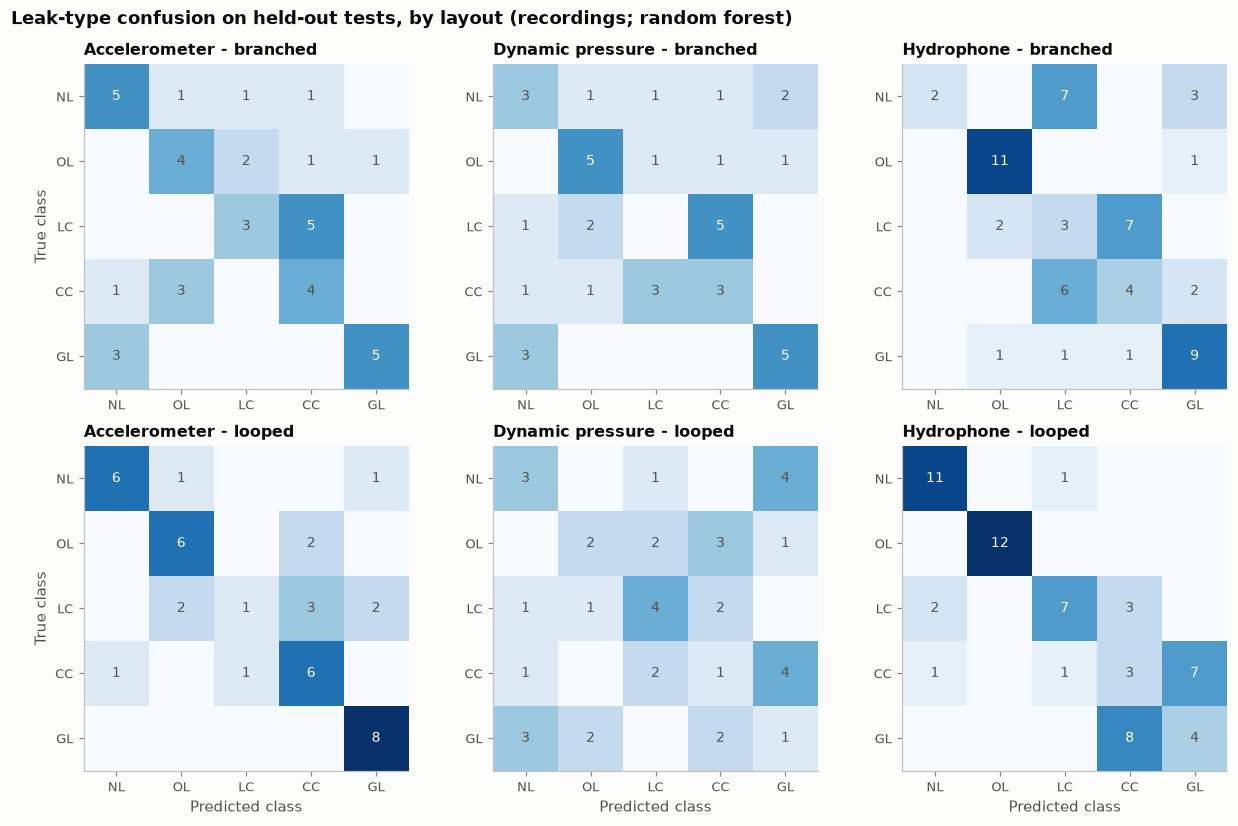

In [7]:
def recording_table(d, task):
    cols = ev.proba_columns(task)
    rec = d.groupby("file", observed=True).agg({**{c: "mean" for c in cols}, "y": "first", "topology": "first", "condition": "first", "sensor": "first"})
    rec["pred"] = rec[cols].to_numpy().argmax(axis=1)
    return rec

fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.6))
for r, (topo_code, topo_name) in enumerate(ld.TOPOLOGIES.items()):
    for c, stype in enumerate("APH"):
        ax = axes[r, c]
        rec = recording_table(ref_oof("type", "grouped_condition", stype), "type")
        rec = rec[rec.topology == topo_code]
        cm = confusion_matrix(rec.y, rec.pred, labels=range(5))
        ax.imshow(cm / cm.sum(axis=1, keepdims=True), cmap=ps.SEQ_CMAP, vmin=0, vmax=1)
        for i in range(5):
            for j in range(5):
                if cm[i, j]:
                    ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9, color="white" if cm[i, j] / cm[i].sum() > 0.55 else ps.INK_2)
        ax.set_xticks(range(5), ld.LEAKS)
        ax.set_yticks(range(5), ld.LEAKS)
        ax.set_title(f"{ld.SENSOR_NAMES[stype]} - {topo_name.lower()}")
        ax.grid(False)
        if c == 0:
            ax.set_ylabel("True class")
        if r == 1:
            ax.set_xlabel("Predicted class")
fig.suptitle("Leak-type confusion on held-out tests, by layout (recordings; random forest)", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

Splitting the held-out-test score by layout shows where it comes from:

- **Hydrophone detection is entirely a looped-layout result:** 0.91 in the looped layout and 0.50, exactly chance, in the branched layout. In the looped layout no-leak is recognised in 11 of 12 recordings; in the branched layout in 2 of 12. This is the single contrast seen in notebook 2 (H2, looped, no-leak) and it does not exist in the other layout.
- **Accelerometer:** somewhat better in the looped layout for both tasks (0.73 against 0.67 for detection, 0.68 against 0.52 for leak type). The looped gasket-leak recordings, which notebook 1 showed to be near the noise floor or carrying interference, are classified correctly 8 times out of 8.
- **Pressure:** weak in both layouts.
- **The two cracks are confused with each other in every panel.** They are the same size (2 mm x 1 mm) and differ only in orientation.

So even the moderately good held-out-test scores are built from layout-specific contrasts, and at least some of those are recording artefacts.

## 3.6 Does signal level help?

Change in recording-level balanced accuracy when `log_rms` is added to the shape features.

In [8]:
cl = metrics[metrics.model.isin(["logreg", "rf", "lgbm"])]
pv = cl.pivot_table(index=["task", "sensor_type", "model", "protocol"], columns="feature_set", values="recording_bal_acc")
pv["gain"] = pv["shape+amplitude"] - pv["shape"]
gain = pv.gain.unstack("protocol")[ev.PROTOCOLS].groupby(["task", "sensor_type"]).mean()
gain = gain.reindex(pd.MultiIndex.from_product([ev.TASKS, list("APH")]))
print("Mean over the three classical models")
gain.rename(index=TASK_NAMES, level=0).rename(index=ld.SENSOR_NAMES, level=1).rename(columns=ev.PROTOCOL_NAMES).round(3)

Mean over the three classical models


protocol                                      Random windows (leaky)  Held-out tests  Held-out flow condition  Held-out pipe layout
Detection (leak vs no-leak) Accelerometer                      0.000           0.003                   -0.010                 0.026
                            Dynamic pressure                   0.003           0.021                    0.003                -0.005
                            Hydrophone                         0.016           0.009                    0.019                -0.014
Leak type (5 classes)       Accelerometer                      0.008          -0.004                   -0.004                 0.008
                            Dynamic pressure                   0.000          -0.000                    0.004                 0.008
                            Hydrophone                         0.008           0.003                    0.011                -0.028

Adding signal level changes balanced accuracy by less than 0.03 in either direction under every protocol. Level carries no usable leak information beyond what the spectral shape already has, which fits notebook 1: level is set by sensor position and layout.

## 3.7 Combining the three sensor types

The sensors are not synchronised, so fusion is done at the level of the physical test: each sensor type's window probabilities are averaged over the test, then the three sensor types are averaged. There are 40 tests, so each number below is a score over 40 decisions.

In [9]:
def condition_probs(task, protocol, stype):
    d = ref_oof(task, protocol, stype)
    cols = ev.proba_columns(task)
    return d.groupby("condition", observed=True).agg({**{c: "mean" for c in cols}, "y": "first"})

rows = []
for task in ev.TASKS:
    cols = ev.proba_columns(task)
    for protocol in ev.PROTOCOLS[1:]:
        per = {s: condition_probs(task, protocol, s) for s in "APH"}
        y = per["A"].y
        row = {"task": TASK_NAMES[task], "protocol": ev.PROTOCOL_NAMES[protocol]}
        for s in "APH":
            row[ld.SENSOR_NAMES[s]] = balanced_accuracy_score(y, per[s].loc[y.index, cols].to_numpy().argmax(axis=1))
        fused = sum(per[s].loc[y.index, cols].to_numpy() for s in "APH") / 3
        row["All three fused"] = balanced_accuracy_score(y, fused.argmax(axis=1))
        rows.append(row)
fusion = pd.DataFrame(rows).set_index(["task", "protocol"])
fusion.round(2)

Accelerometer  Dynamic pressure  Hydrophone  All three fused
task                        protocol                                                                             
Detection (leak vs no-leak) Held-out tests                    0.73              0.55        0.75             0.62
                            Held-out flow condition           0.75              0.81        0.81             0.69
                            Held-out pipe layout              0.44              0.55        0.75             0.56
Leak type (5 classes)       Held-out tests                    0.68              0.40        0.68             0.72
                            Held-out flow condition           0.82              0.72        0.88             0.92
                            Held-out pipe layout              0.22              0.20        0.20             0.18

- **Leak type inside the training conditions benefits from fusion:** 0.72 on held-out tests and 0.92 on a held-out flow condition, better than any single sensor type.
- **Detection does not benefit.** The fused score is below the best single sensor type under every protocol.
- **Fusion does not rescue a held-out layout:** 0.18 for leak type, below chance.

The hydrophone's 0.75 for detection on a held-out layout stands out, but it is a score over 40 tests of which only 8 are no-leak, and its recording-level interval in the next section includes chance.

## 3.8 How certain are these numbers?

There are only 40 independent tests. To put an interval on the reference model's scores, the tests are resampled with replacement 2,000 times and the recording-level balanced accuracy is recomputed each time.

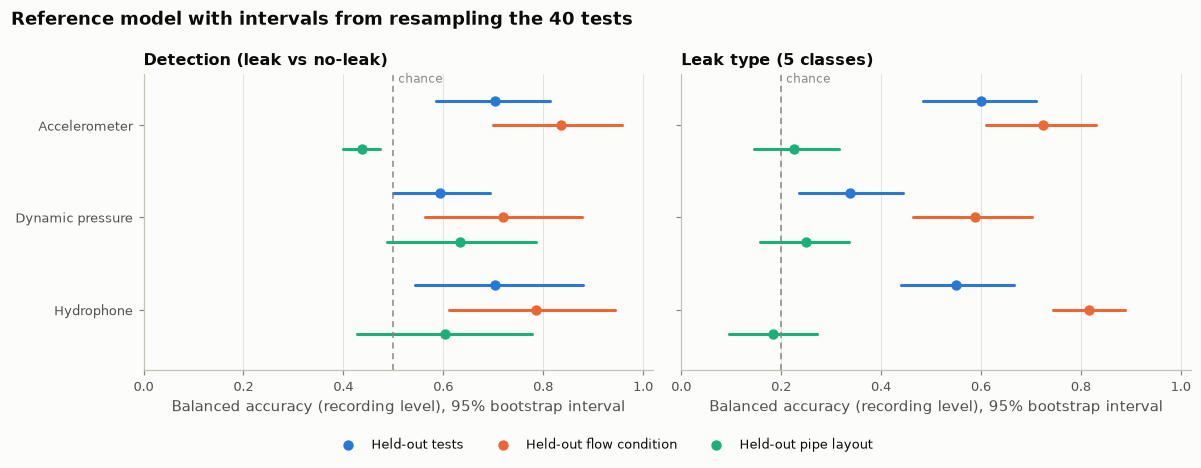

protocol                                           Held-out tests Held-out flow condition Held-out pipe layout
Detection (leak vs no-leak) Accelerometer     0.70 (0.59 to 0.81)     0.84 (0.70 to 0.96)  0.44 (0.40 to 0.47)
                            Dynamic pressure  0.59 (0.50 to 0.69)     0.72 (0.56 to 0.88)  0.63 (0.49 to 0.79)
                            Hydrophone        0.70 (0.54 to 0.88)     0.79 (0.61 to 0.94)  0.60 (0.43 to 0.78)
Leak type (5 classes)       Accelerometer     0.60 (0.48 to 0.71)     0.72 (0.61 to 0.83)  0.23 (0.14 to 0.32)
                            Dynamic pressure  0.34 (0.24 to 0.44)     0.59 (0.46 to 0.70)  0.25 (0.16 to 0.34)
                            Hydrophone        0.55 (0.44 to 0.67)     0.82 (0.75 to 0.89)  0.18 (0.10 to 0.27)

In [10]:
def bootstrap_ci(rec, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    groups = {k: g[["y", "pred"]].to_numpy() for k, g in rec.groupby("condition")}
    keys = list(groups)
    scores = []
    for _ in range(n_boot):
        sample = np.concatenate([groups[k] for k in rng.choice(keys, len(keys))])
        if len(np.unique(sample[:, 0])) < len(np.unique(rec.y)):
            continue
        scores.append(balanced_accuracy_score(sample[:, 0], sample[:, 1]))
    return np.percentile(scores, [2.5, 97.5])

rows = []
for task in ev.TASKS:
    for stype in "APH":
        for protocol in ev.PROTOCOLS[1:]:
            rec = recording_table(ref_oof(task, protocol, stype), task)
            lo, hi = bootstrap_ci(rec)
            rows.append(dict(task=task, stype=stype, protocol=protocol, score=balanced_accuracy_score(rec.y, rec.pred), lo=lo, hi=hi))
ci = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, task in zip(axes, ev.TASKS):
    d = ci[ci.task == task]
    ypos = 0
    ticks, labels = [], []
    for stype in "APH":
        for protocol in ev.PROTOCOLS[1:]:
            row = d[(d.stype == stype) & (d.protocol == protocol)].iloc[0]
            ax.plot([row.lo, row.hi], [ypos, ypos], color=ps.PROTOCOL_COLORS[protocol], lw=2, solid_capstyle="round")
            ax.scatter(row.score, ypos, s=46, color=ps.PROTOCOL_COLORS[protocol], zorder=3, linewidths=0,
                       label=ev.PROTOCOL_NAMES[protocol] if stype == "A" else None)
            ypos += 1
        ticks.append(ypos - 2)
        labels.append(ld.SENSOR_NAMES[stype])
        ypos += 0.8
    ax.axvline(CHANCE[task], color=ps.MUTED, lw=1, ls=(0, (4, 3)))
    ax.text(CHANCE[task] + 0.01, -0.75, "chance", fontsize=8, color=ps.MUTED)
    ax.set_yticks(ticks, labels)
    ax.set_xlim(0, 1.02)
    ax.set_ylim(ypos - 0.3, -1.1)
    ax.set_xlabel("Balanced accuracy (recording level), 95% bootstrap interval")
    ax.set_title(TASK_NAMES[task])
    ax.grid(axis="y", visible=False)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0))
fig.suptitle("Reference model with intervals from resampling the 40 tests", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()
ci["text"] = ci.score.map("{:.2f}".format) + " (" + ci.lo.map("{:.2f}".format) + " to " + ci.hi.map("{:.2f}".format) + ")"
ci_table = ci.pivot(index=["task", "stype"], columns="protocol", values="text")[ev.PROTOCOLS[1:]]
ci_table = ci_table.reindex(pd.MultiIndex.from_product([ev.TASKS, list("APH")]))
ci_table.rename(index=TASK_NAMES, level=0).rename(index=ld.SENSOR_NAMES, level=1).rename(columns=ev.PROTOCOL_NAMES)

- **Intervals are wide.** With 40 tests, most scores are uncertain by about 0.1 to 0.2 in each direction.
- **Held-out tests and held-out flow are clearly above chance** for leak type on every sensor type, and for detection on the accelerometer and hydrophone.
- **Held-out layout is not distinguishable from chance** in any case. The one interval that excludes chance, accelerometer detection, lies below it: what the model learned about leaks in one layout is misleading in the other.

## 3.9 What the reference model uses

Random forest feature importances for the leak-type task, fitted on all recordings of each sensor type. These show what the model relies on, not what a leak physically does.

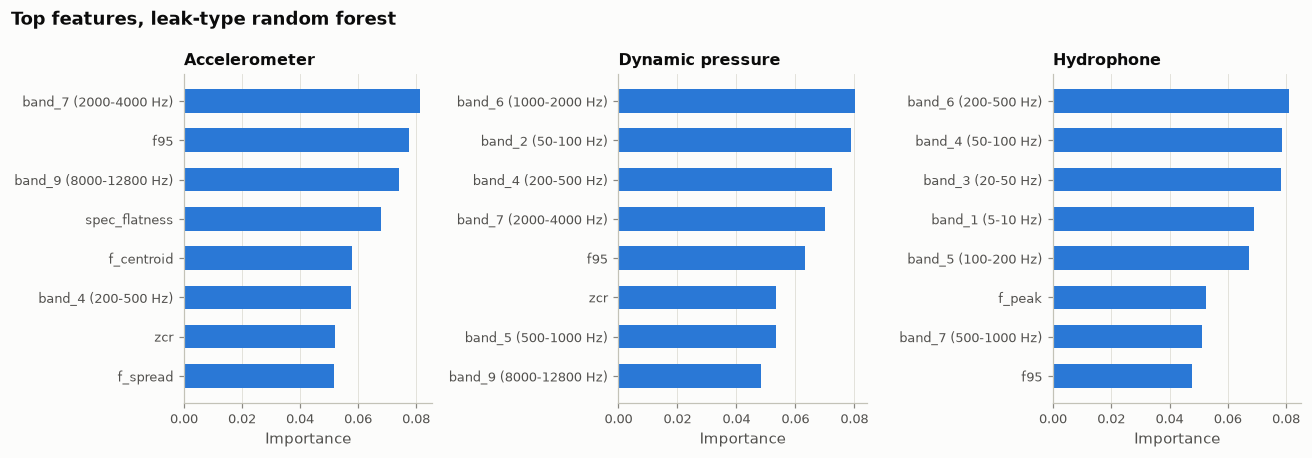

In [11]:
feats = pd.read_parquet(ld.PROCESSED / "features.parquet")
feats = feats[feats.leak != "BG"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, stype in zip(axes, "APH"):
    d = feats[feats.sensor_type == stype]
    rf = ev.make_model("rf").set_params(n_jobs=-1).fit(d[ft.SHAPE_FEATURES], ev.target(d, "type"))
    imp = pd.Series(rf.feature_importances_, index=ft.SHAPE_FEATURES).sort_values().tail(8)
    names = [f"{c} ({ft.BANDS[stype][int(c[-1])]}-{ft.BANDS[stype][int(c[-1]) + 1]} Hz)" if c.startswith("band_") else c for c in imp.index]
    ax.barh(names, imp.values, color="#2a78d6", height=0.6)
    ax.set_title(ld.SENSOR_NAMES[stype])
    ax.set_xlabel("Importance")
    ax.grid(axis="y", visible=False)
fig.suptitle("Top features, leak-type random forest", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

Importance is spread over many spectral features, with no single dominant one. For the accelerometer the top features describe high-frequency content (energy above 2 kHz, the 95% frequency, spectral flatness), which is exactly what separates the interference and noise-floor recordings from ordinary flow noise.

## 3.10 Conclusions

**What the models can do.** Inside the conditions they were trained on, they recognise which class a new recording belongs to well above chance: fusing the three sensor types gives 0.72 balanced accuracy over five classes on held-out tests and 0.92 on a held-out flow condition.

**What they cannot do.** Nothing learned in one pipe layout transfers to the other. Leak type falls to chance, and detection is not distinguishable from chance. This holds for every sensor type, every model and both training directions.

**What that means.** The models are recognising groups of recordings, not leaks. The class differences they use exist within one layout and vanish in the other, and notebook 1 showed that at least some of them are instrumentation artefacts. On this evidence the dataset does not support a claim of leak detection that would generalise to another network, and the high accuracies obtainable from a random split are an artefact of evaluation.

**Secondary findings.**

- A random split of windows overstates leak-type accuracy by about 0.40 against held-out tests and by more than 0.60 against a held-out layout.
- Model family matters little. A CNN on spectrograms gains nothing consistent over a random forest on 22 hand-made features, and loses more when conditions change.
- Signal level adds nothing to spectral shape.
- Fusing sensor types helps leak-type classification but not detection.

**Limits of this study.**

- Hyperparameters were fixed, not tuned, so better within-condition scores are certainly possible. That would not address the transfer failure.
- There are 40 physical tests and two layouts. The cross-layout result is a single pair of train/test directions.
- No domain-adaptation or per-layout normalisation method was tried.

**What a dataset would need for this question to be answerable.**

- Repeated tests of every class, recorded in separate sessions and in randomised order, so that class and session are not tied together.
- A no-leak baseline recorded immediately before each leak test, with the sensors untouched.
- Synchronised sensor pairs, so that cross-correlation and localisation become possible.
- More than two network layouts.